In [1]:
##############################################################################
# AI & OPTIMIZATION - LAB 05 - 2025/2026
##############################################################################

In [2]:
# System imports
import matplotlib.pyplot as plt
import numpy as np

#Extra library imports
import pandas as pd
from scipy.optimize import linprog
from scipy.optimize import minimize

In [3]:
# User inputs
csvfile = 'data.csv'

A portfolio is a combination of financial investments, such as stocks. Ideally, an investor seeks to maximize his return on investment while minimizing the risk. Such tradeoff was modelled as a nonlinear constrained optimization problem in the Modern Portfolio Theory, formulated in 1952 by the economist Harry Markowitz. In this lab, we will implement this model for portfolio optimization on real-case examples.

# I. Portfolio optimization using the Modern Portfolio Theory

## a) Exploration of the dataset

A company's profitability can be measured evaluating its Return On Assets (ROA), namely the ratio between its turnover and its total number of assets. We will work on ROAs given for real world companies over five consecutive years.

<font color='blue'> Question 1: open the 'data.csv' file using pandas. Assign a variable "nb_companies" with the number of companies, for example using the "shape" attribute of Pandas. </font>

In [4]:
# Load the first csv file
df = pd.read_csv(csvfile)

nb_companies = df.shape[0]
print('{0} companies'.format(nb_companies))

# Display the dataframe
print(df)

4 companies
  Company  ROA-Y01  ROA-Y02  ROA-Y03  ROA-Y04  ROA-Y05
0      C1     4.57     4.18     3.80     3.56     4.45
1      C2     7.30     7.52     3.19     3.21     6.24
2      C3     2.98     2.74     2.65     2.54     2.76
3      C4     1.25     1.12     1.36     0.99     0.91


We read for example that the first company achieved a ROA of 4.57% on the first given year. To model the investment distribution, we need to convert these percentages (in [0, 100]) into decimal values (in [0, 1]). For example, the decimal value of the ROA of the first company on the first year is 0.0457.

<font color='blue'> Question 2: convert the ROA values into decimal values.</font> 

In [5]:
# Get the list of feature names
featnames = df.columns[1:]

# Convert each ROA value into decimal value
df[featnames] = df[featnames]/100

# Display the result
print(df)

  Company  ROA-Y01  ROA-Y02  ROA-Y03  ROA-Y04  ROA-Y05
0      C1   0.0457   0.0418   0.0380   0.0356   0.0445
1      C2   0.0730   0.0752   0.0319   0.0321   0.0624
2      C3   0.0298   0.0274   0.0265   0.0254   0.0276
3      C4   0.0125   0.0112   0.0136   0.0099   0.0091


In [6]:
print(df[featnames])

   ROA-Y01  ROA-Y02  ROA-Y03  ROA-Y04  ROA-Y05
0   0.0457   0.0418   0.0380   0.0356   0.0445
1   0.0730   0.0752   0.0319   0.0321   0.0624
2   0.0298   0.0274   0.0265   0.0254   0.0276
3   0.0125   0.0112   0.0136   0.0099   0.0091


To optimize our portfolio, we then need to compute statistical measures. We start with the mean and the standard deviation of the ROA over the five years.

<font color='blue'> Question 3: compute the mean and the standard deviation of the ROA values over the five years for each company using the *mean* and *std* attributes of pandas. Get automatically the name of the company having the lowest and highest value for each statistical measure. What is the riskiest investment? </font> 

In [7]:
# Array of company names
companies = df['Company'].values

# Compute the array of mean ROAs 
mean_roas = df[featnames].mean(axis=1)

# Compute the array of standard deviation ROAs
std_roas = df[featnames].std(axis=1)

# Display some statistics:
print(f'Company with the highest mean ROA: { mean_roas.idxmax()}')
print(f'Company with the lowest mean ROA: { mean_roas.idxmin()}')
print(f'Company with the highest std ROA: { std_roas.idxmax()}')
print(f'Company with the lowest std ROA: { std_roas.idxmin()}')

Company with the highest mean ROA: 1
Company with the lowest mean ROA: 3
Company with the highest std ROA: 1
Company with the lowest std ROA: 2


<font color='green'> To complete   
</font> 

Usually, the returns are not independent. To that purpose, our model will also rely on the correlation between pairs of returns.

<font color='blue'> Question 4: compute the correlation between companies' ROAs using the *corr* attribute of pandas. Are the companies' ROAs independent from each other?</font> 

In [8]:
# On transpose pour calculer la corrélation entre entreprises (lignes) et non entre années
corr_roas = df[featnames].T.corr()

print(corr_roas) # Doit être une matrice 4x4

          0         1         2         3
0  1.000000  0.870688  0.917191 -0.046304
1  0.870688  1.000000  0.795833 -0.112570
2  0.917191  0.795833  1.000000  0.263780
3 -0.046304 -0.112570  0.263780  1.000000


<font color='green'> To complete    
</font> 

We have now everything to model our optimal portfolio!

## b) Portfolio optimization using linear programming

We start with a simple model, where the investor seeks to maximize his ROA, without considering the risk. We also assume that all the available funds should be divided into the proposed assets. 
We formulate this decision making process as the following linear programming problem:

$\max \Biggl \{ \displaystyle \sum_{i=1}^n x_i m_i  \Biggl \} $ s.t. $\displaystyle \sum_{i=1}^n x_i = 1$, $x_i$ $\in$ [0, 1]

with $n$ the number of assets, each one associated with a company, $x_i$ the fraction of funds to put in asset $i$, and $m_i$ the mean ROA of asset $i$.
The vector of variables to optimize is $\boldsymbol x = (x_1, ..., x_n)$.
Thus, this model maximizes the expected return of the portfolio (with $\displaystyle \sum_{i=1}^n x_i r_i$ the return of the portfolio, $r_i$ being the return of asset $i$).

We will now solve this linear programming problem using Scipy.

<font color='blue'> Question 5: complete the code below to solve this problem using the linprog function of Scipy. As usually, look at the online documentation of this function.</font> 

In [9]:
# Set the coefficients of the linear objective function to be minimized
c = -mean_roas.values

# Set the equality constraint matrix
A_eq = [np.ones(nb_companies)]

# Set the equality constraint vector
b_eq = [1]

# Set the bounds
bounds = [(0, 1) for _ in range(nb_companies)]

# Perform the optimization 
res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds)#

# Display the optimization result
print(res)

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -0.05491999999999999
              x: [ 0.000e+00  1.000e+00  0.000e+00  0.000e+00]
            nit: 0
          lower:  residual: [ 0.000e+00  1.000e+00  0.000e+00  0.000e+00]
                 marginals: [ 1.380e-02  0.000e+00  2.758e-02  4.366e-02]
          upper:  residual: [ 1.000e+00  0.000e+00  1.000e+00  1.000e+00]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
          eqlin:  residual: [ 0.000e+00]
                 marginals: [-5.492e-02]
        ineqlin:  residual: []
                 marginals: []
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0


<font color='blue'> Question 6: compute automatically and display in percentage the optimized expected return on the portfolio, *i.e* the objective function to maximize. </font> 

In [10]:
optimized_return = -res.fun
print(f"Optimized expected return: {optimized_return * 100:.2f} %")

Optimized expected return: 5.49 %


<font color='blue'> Question 7: display automatically the percentage of funds to invest in each company. What is the limit of such investment strategy? </font> 

In [11]:
for i in range(nb_companies):
    print(f"Investment in {companies[i]}: {res.x[i] * 100:.2f}%")

Investment in C1: 0.00%
Investment in C2: 100.00%
Investment in C3: 0.00%
Investment in C4: 0.00%


<font color='green'> WTF ALL IN in one company never do that exepct if you want to be brocke </font> 

## c) Portfolio optimization using nonlinear programming

In practice, the model proposed in the previous section is not used, because the expected ROA can be increased taking higher risks. However, taking many risk is counterproductive. The tradeoff between risk and return was modelled by Markowitz in 1952 solving the following problem:

$\max \Biggl \{ \displaystyle \sum_{i=1}^n x_i m_i - k \sum_{i=1}^n\sum_{j=1}^n x_i x_j s_i s_j c_{ij} \Biggl \}  $ s.t. $\displaystyle \sum_{i=1}^n x_i = 1$, $x_i$ $\in$ [0, 1] 

with $n$ the number of assets, $x_i$ the fraction of funds to put in asset $i$, $m_i$ the mean ROA of asset $i$, $s_i$ the standard deviation ROA of asset $i$ and $c_{ij}$ the correlation between asset $i$ and $j$. $k$ is a strictly positive hyperparameter making the tradeoff between risk and return.
Thus, this model maximizes the expected return of the portfolio $\Biggl ( \displaystyle \sum_{i=1}^n x_i m_i \Biggl )$ while minimizing the expected variance of the portfolio $ \Biggl ( \displaystyle \sum_{i=1}^n\sum_{j=1}^n x_i x_j s_i s_j c_{ij} \Biggl )$.
The vector of variables to optimize is still $\boldsymbol x = (x_1, ..., x_n)$.

We will now solve this nonlinear programming problem using the Sequential Least Squares Programming (SLSQP) method of Scipy, based on Sequential Quadratic Programming (SQP).

<font color='blue'> Question 8: complete the *loss_function* and *gradient_loss* functions. </font> 

In [18]:
def loss_function(x, m, s, c, k):
    """
    Loss function (i.e. the objective function TO MINIMIZE)
    
    Inputs
    ----------
    x: vector of n floats
        the vector x with the n variables to optimize: x = [x_1, ...,  x_n]
    m: vector of n floats
        the vector containing the mean ROA
    s: vector of n floats
        the vector containing the standard deviation ROA
    c: n x n array of float values
        the ROA correlation
    k: float > 0
        the hyperparameter controlling the tradeoff between risk and return
        
    Outputs
    -------
    loss_val: float
        the loss value
        
    Command:
    loss_val = loss_function(x, m, s, c, k)
    
    """
    x = np.array(x)
    m = np.array(m)
    s = np.array(s)
    c_mat = c.values if hasattr(c, 'values') else np.array(c)
    
    # 1. Rendement : produit scalaire
    return_val = np.sum(x * m)

    # 2. Variance : x.T @ Sigma @ x
    S = np.diag(s)
    sigma = S @ c_mat @ S
    var_val = x.T @ sigma @ x
    
    # 3. Calcul de la perte
    loss_val = k * var_val - return_val
    
    # Correction de la parenthèse ici :
    return float(np.asarray(loss_val).item())
    

In [19]:
def gradient_loss(x, m, s, c, k):
    """
    Gradient of the loss function (i.e. the objective function TO MINIMIZE)
    
    Inputs
    ----------
    x: vector of n floats
        the vector x with the n variables to optimize: x = [x_1, ...,  x_n]
    m: vector of n floats
        the vector containing the mean ROA
    s: vector of n floats
        the vector containing the standard deviation ROA
    c: n x n array of float valuesdef loss_function(x, m, s, c, k):
    x = np.array(x)
    m = np.array(m)
    s = np.array(s)
    c_mat = c.values if hasattr(c, 'values') else np.array(c)
    
    # 1. Rendement : produit scalaire
    return_val = np.sum(x * m)

    # 2. Variance : x.T @ Sigma @ x
    S = np.diag(s)
    sigma = S @ c_mat @ S
    var_val = x.T @ sigma @ x
    
    # 3. Calcul de la perte
    loss_val = k * var_val - return_val
    
    # Correction de la parenthèse ici :
    return float(np.asarray(loss_val).item())
        the ROA correlation
    k: float > 0
        the hyperparameter controlling the tradeoff between risk and return
        
    Outputs
    -------
    grad_vec: vector of floats
        the gradient
        
    Command:
    grad_vec = gradient_loss(x, m, s, c, k)
    
    """
    x = np.array(x)
    m = np.array(m)
    
    # 1. Gradient du rendement attendu : la dérivée de sum(x_i * m_i) est m_i
    grad_return = m
    
    # 2. Gradient de la variance attendue
    # On calcule d'abord la matrice de covariance Sigma_ij = s_i * s_j * c_ij
    S = np.diag(s)
    sigma = S @ c @ S # Matrice de covariance
    
    # La dérivée de la forme quadratique (x.T @ sigma @ x) est 2 * sigma @ x
    grad_var = 2 * (sigma @ x)
      
    # 3. Gradient de la perte totale à MINIMISER
    # f(x) = k * var - return  => grad = k * grad_var - grad_return
    grad_vec = k * grad_var - grad_return

    return grad_vec

You can apply your function on a given vector to check your implementation.

In [20]:
# Test your loss function
loss_val = loss_function([0.1, 0.2, 0.3, 0.4], mean_roas, std_roas, corr_roas,
                         1000)
print(loss_val)

# Test your gradient function
grad_val = gradient_loss([0.1, 0.2, 0.3, 0.4], mean_roas, std_roas, corr_roas,
                         1000)
print(grad_val)

-0.002026129999999994
0   -0.001964
1    0.158672
2   -0.012719
3   -0.009931
dtype: float64


You should obtain -0.002026129999999994 for the loss value and [-0.0019636  0.1586719 -0.0127192 -0.0099313] for the gradient vector.

We can now apply the model, trying different values for the $k$ hyperparameter.

<font color='blue'> Question 9: complete the following code to apply the Markowitz's model on our data. Initialize the vector of variables to optimize with the result obtained in section b). Then, apply Sequential Least Squares Programming using the minimize function of Scipy with the appropriate arguments - and notably, you should call the two functions created on the previous question. Try different values of k from 0 to 100. </font> 

In [21]:
# Initial x vector : on commence avec une répartition équitable (25% partout)
x0 = np.ones(nb_companies) / nb_companies

# Bounds : chaque x_i doit être entre 0 et 1
bounds = [(0, 1) for _ in range(nb_companies)]

# Dictionnaire de contraintes : la somme des x_i doit être égale à 1
# 'fun' doit être égal à 0 pour que la contrainte soit respectée, donc sum(x) - 1
eq_cons = {'type': 'eq',
           'fun' : lambda x: np.sum(x) - 1,
           'jac' : lambda x: np.ones(len(x))} 

# Méthode d'optimisation
method = 'SLSQP'

# Initialisation des listes
scores = []
xs = []
expected_returns = []
expected_variances = []

# Matrice de covariance Sigma (utile pour calculer la variance finale)
S = np.diag(std_roas)
sigma = S @ corr_roas.values @ S

# Boucle de 0 à 100
for k in range(101):
    # Optimisation
    res_k = minimize(loss_function, x0, args=(mean_roas.values, std_roas.values, corr_roas, k),
                     method=method, jac=gradient_loss, constraints=eq_cons, bounds=bounds)

    # Valeur de la fonction objectif à MAXIMISER (on reprend l'opposé car res_k.fun est la perte)
    scores.append(-res_k.fun)

    # Rendement attendu (sum x_i * m_i)
    ret = np.dot(res_k.x, mean_roas.values)
    expected_returns.append(ret)

    # Variance attendue (x.T @ sigma @ x)
    var = res_k.x.T @ sigma @ res_k.x
    expected_variances.append(var)
    
    # Sauvegarde des poids optimisés
    xs.append(res_k.x)

xs = np.array(xs)

<font color='blue'> Question 10: display the evolution of the objective function to maximize in function of k.  </font> 

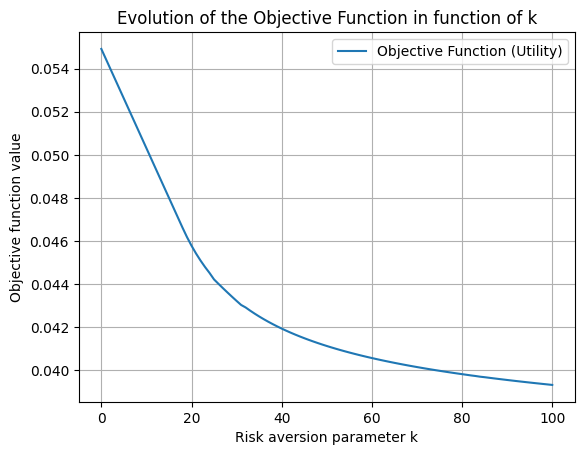

In [22]:
# Création du graphique
plt.plot(range(101), scores, label='Objective Function (Utility)')

# Ajout des labels et du titre
plt.xlabel('Risk aversion parameter k')
plt.ylabel('Objective function value')
plt.title('Evolution of the Objective Function in function of k')
plt.grid(True)
plt.legend()

# Affichage/Sauvegarde
plt.savefig('objective_function_k.png')

<font color='blue'> Question 11: display the evolution of the optimal expected return and expected variance of the portfolio in function of k. What is the minimal value of k to choose to start reducing the risk? </font> 

Minimal value of k to start reducing the risk: 19


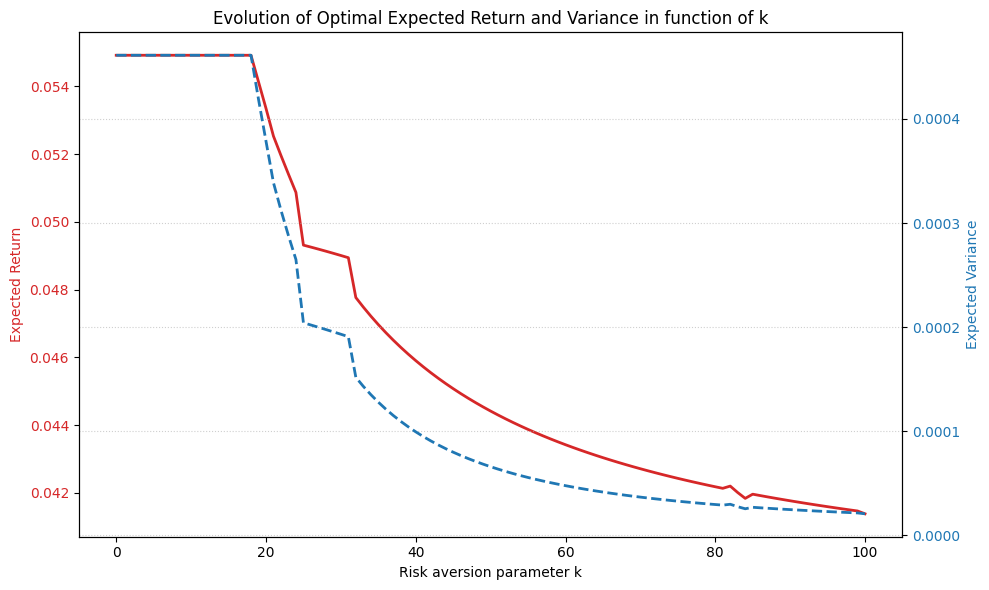

In [24]:
# Création de la figure et du premier axe (pour le rendement)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Risk aversion parameter k')
ax1.set_ylabel('Expected Return', color=color)
ax1.plot(range(101), expected_returns, color=color, linewidth=2, label='Return')
ax1.tick_params(axis='y', labelcolor=color)

# Création du second axe (pour la variance) partageant le même axe x
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Expected Variance', color=color)  
ax2.plot(range(101), expected_variances, color=color, linewidth=2, linestyle='--', label='Variance')
ax2.tick_params(axis='y', labelcolor=color)

# Titre et affichage
plt.title('Evolution of Optimal Expected Return and Variance in function of k')
plt.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()
plt.savefig('return_variance_k.png')

# Calcul automatique du k minimal pour réduire le risque
k_min = 0
initial_variance = expected_variances[0]
for k in range(1, 101):
    if expected_variances[k] < initial_variance - 1e-7: # 1e-7 pour ignorer le bruit numérique
        k_min = k
        break

print(f"Minimal value of k to start reducing the risk: {k_min}")

<font color='green'> To complete</font> 

<font color='blue'> Question 12: display the evolution of the optimal value of each variable $x_i$ in function of $k$. Comment. What strategy should follow an investor who does not want to take any risk? What is the most balanced strategy - and more particularly, what is the associated k value? Compute the associated optimal expected return.</font> 

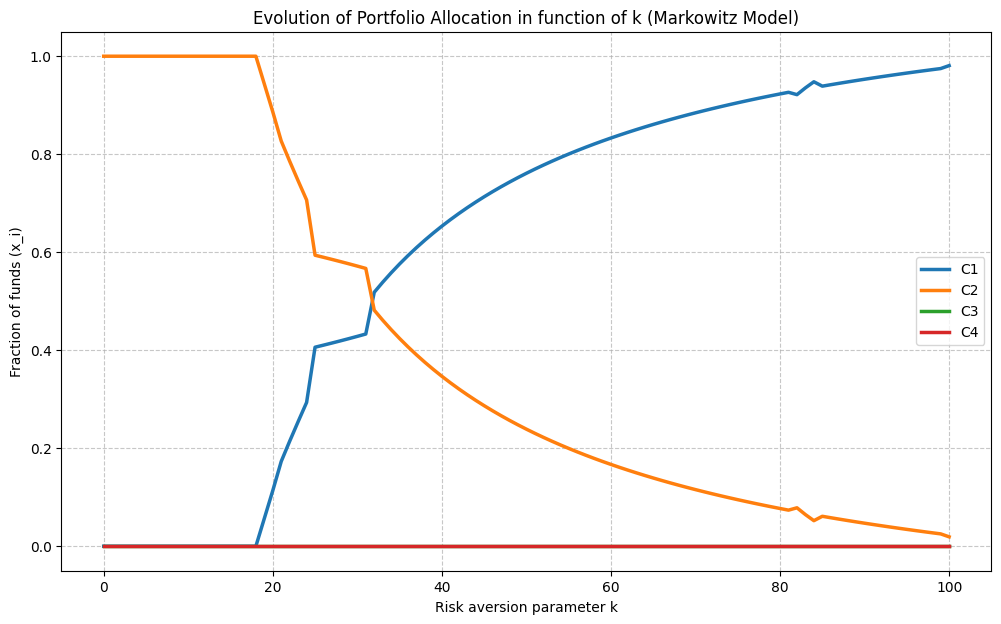

In [25]:
plt.figure(figsize=(12, 7))

# On trace l'évolution du poids de chaque entreprise
for i in range(nb_companies):
    plt.plot(range(101), xs[:, i], label=companies[i], linewidth=2.5)

plt.xlabel('Risk aversion parameter k')
plt.ylabel('Fraction of funds (x_i)')
plt.title('Evolution of Portfolio Allocation in function of k (Markowitz Model)')
plt.legend(loc='center right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('portfolio_allocation_k.png')

<font color='green'> To complete </font> 